In [26]:
import numpy as np
import pandas as pd
import MDAnalysis as mda
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from tqdm.auto import trange


In [27]:
def distances_from_multistate_pdb(pdb_file, atomid1=644, atomid2=997):
    u = mda.Universe(pdb_file)
    dists = []

    a1 = u.select_atoms(f"id {atomid1}")
    a2 = u.select_atoms(f"id {atomid2}")
  #  if len(a1) != 1 or len(a2) != 1:
  #      raise ValueError("Expected exactly one atom for each atom id.")
    #print(len(a1.positions))
    #print(a1.positions)
    for i in range(len(a1.positions)):
        d = np.linalg.norm(a1.positions[i] - a2.positions[i])
#        print(d)   
        dists.append(float(d))

    return dists

In [28]:
def bootstrap_kde(
    dk_replicas: list[list[float]],
    output_csv: str,
    n_bootstrap: int = 4000,
    confidence_level: float = 95,
    x_min: float = 2,
    x_max: float = 12,
    n_points: int = 100,
    bw_scale: float = 0.6
):
    dk_all = [item for sublist in dk_replicas for item in sublist]
    x_grid = np.linspace(x_min, x_max, n_points)

    kde_samples = np.zeros((n_bootstrap, len(x_grid)))
    print("len(dk_replicas):", len(dk_replicas))
    print("len(dk_replicas[0]):", len(dk_replicas[0]))
    print("first few values:", dk_replicas[0][:5])
    for i in trange(n_bootstrap, desc="Bootstrap KDE"):
        sample = np.random.choice(dk_all, size=len(dk_all), replace=True)
        kde = gaussian_kde(sample)
        kde.set_bandwidth(bw_method=kde.factor * bw_scale)
        kde_samples[i, :] = kde(x_grid)

    lower_bound = np.percentile(kde_samples, (100 - confidence_level) / 2, axis=0)
    upper_bound = np.percentile(kde_samples, 100 - (100 - confidence_level) / 2, axis=0)
    kde_mean = np.mean(kde_samples, axis=0)
    kde_std = np.std(kde_samples, axis=0)
    kde_std_norm = kde_std / kde_mean.max()
    kde_mean_norm = kde_mean / kde_mean.max()
    lower_bound_norm = lower_bound / kde_mean.max()
    upper_bound_norm = upper_bound / kde_mean.max()

    df_out = pd.DataFrame({
        "x": x_grid,
        "kde_mean": kde_mean,
        "kde_mean_norm": kde_mean_norm, 
        "kde_std": kde_std,
        "kde_std_norm": kde_std_norm,
        "ci_lower": lower_bound,
        "ci_upper": upper_bound,
        "ci_lower_norm": lower_bound_norm,
        "ci_upper_norm": upper_bound_norm
    })
    df_out.to_csv(output_csv, index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(x_grid, kde_mean_norm, label="mean KDE")
    plt.fill_between(
        x_grid,
        lower_bound_norm,
        upper_bound_norm,
        alpha=0.3,
        label=f"CI {confidence_level}%"
    )
    plt.xlabel("distance")
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_out

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [9.453411102294922, 7.230024814605713, 7.281492710113525, 9.310044288635254, 7.66813850402832]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

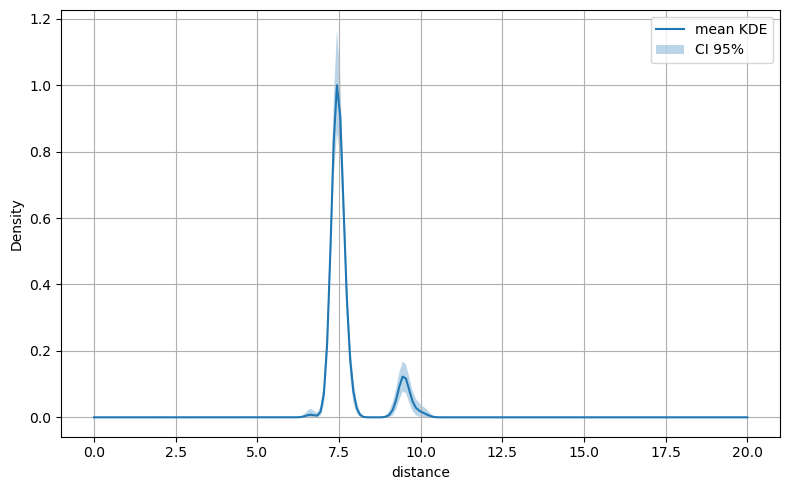

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.2528228759765625, 7.232676982879639, 7.2458720207214355, 7.292926788330078, 7.310330867767334]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

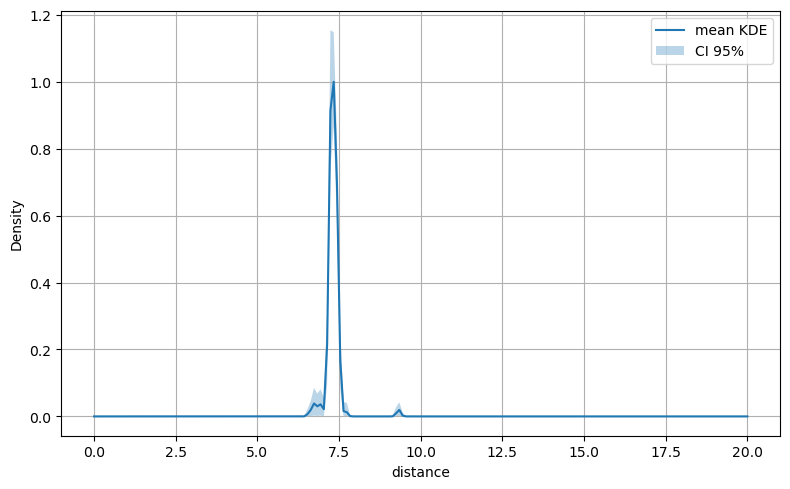

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.520403861999512, 7.280125617980957, 7.382819175720215, 7.447566509246826, 7.679771423339844]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

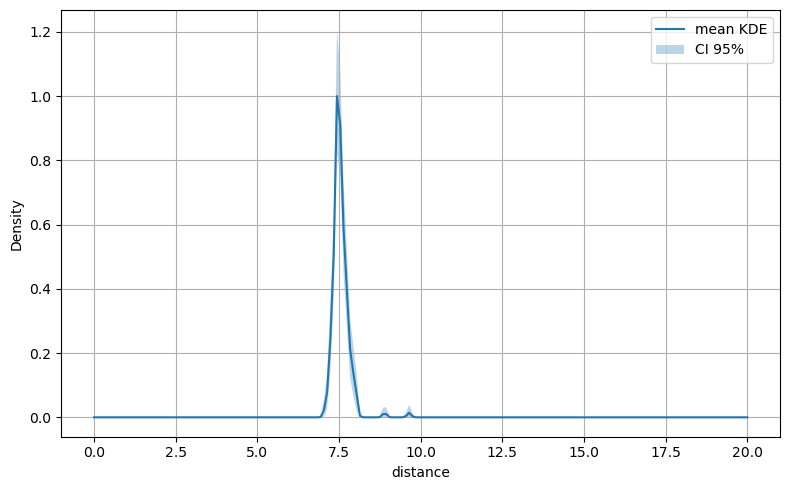

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.342944622039795, 7.280485153198242, 7.2513322830200195, 7.298089504241943, 7.325056552886963]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

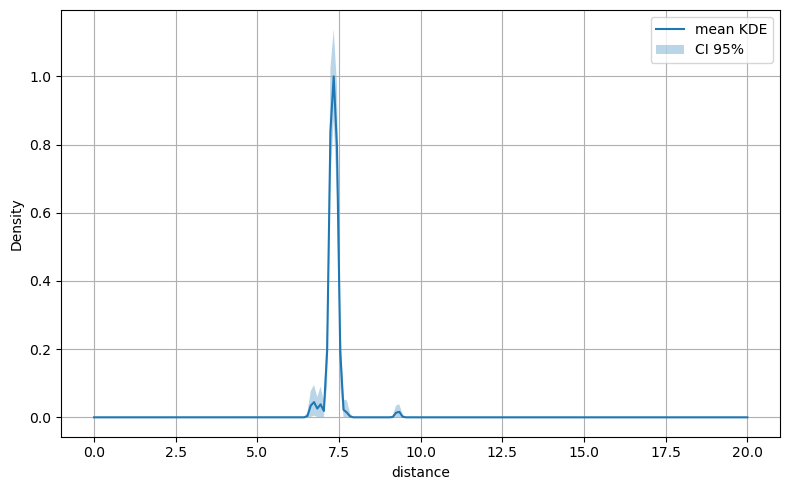

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.522119045257568, 7.375264644622803, 7.383980751037598, 7.518544673919678, 7.3533735275268555]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

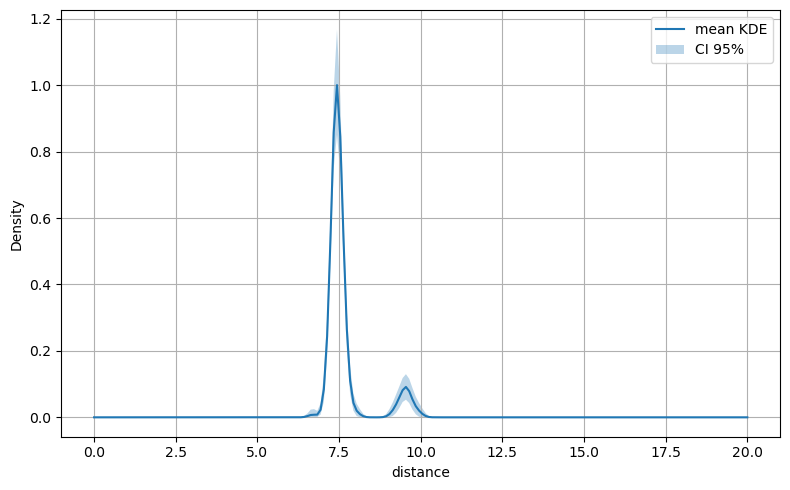

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.538394927978516, 7.320187568664551, 7.334264755249023, 7.413908958435059, 7.221023082733154]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

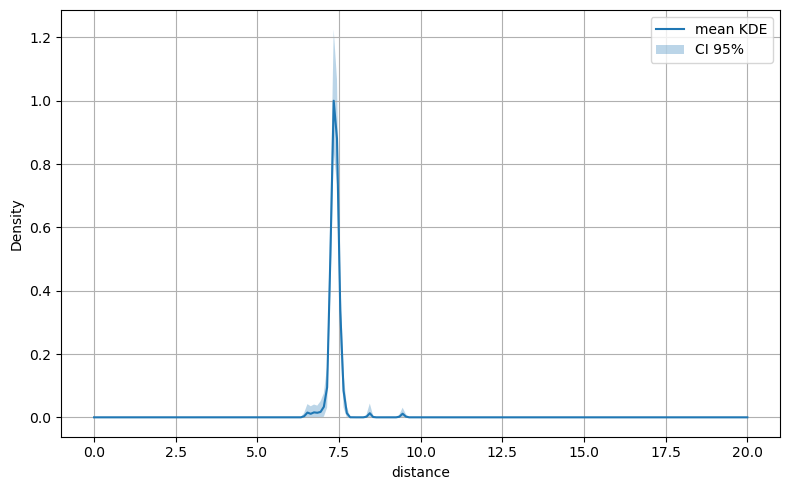

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.00020694732666, 7.032532215118408, 7.132120609283447, 7.101889133453369, 7.022403240203857]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

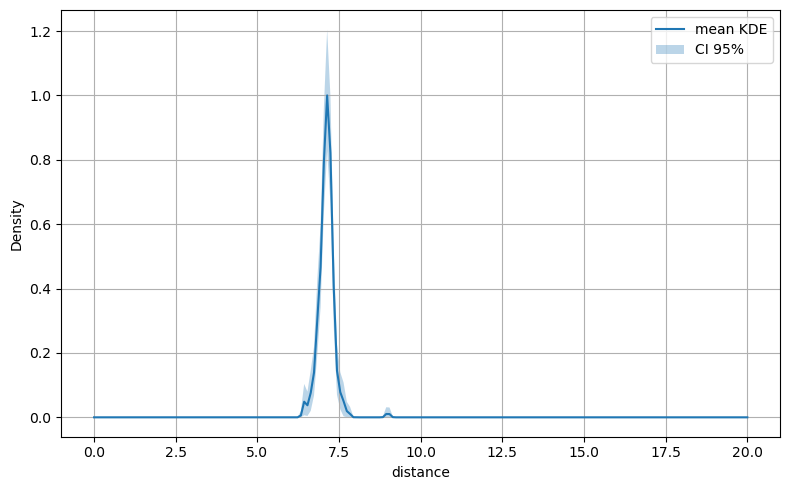

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.437528610229492, 7.03439998626709, 6.96607780456543, 6.966763496398926, 6.960310459136963]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

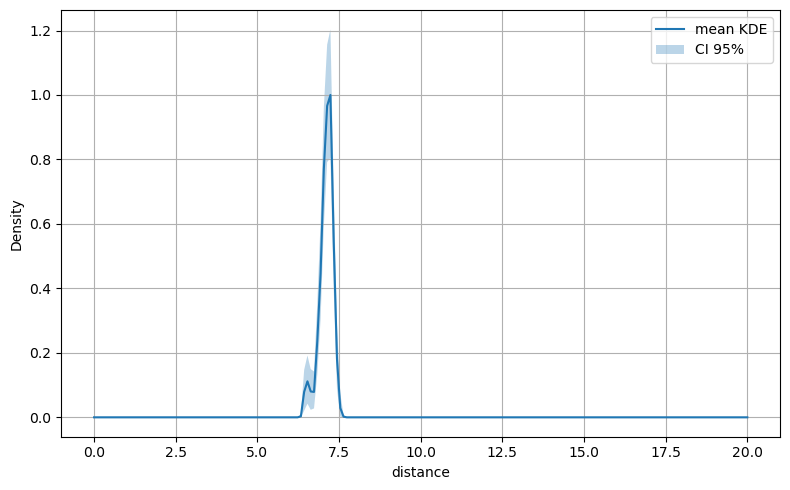

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.255000591278076, 7.311644554138184, 7.225957870483398, 7.280892848968506, 7.123530864715576]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

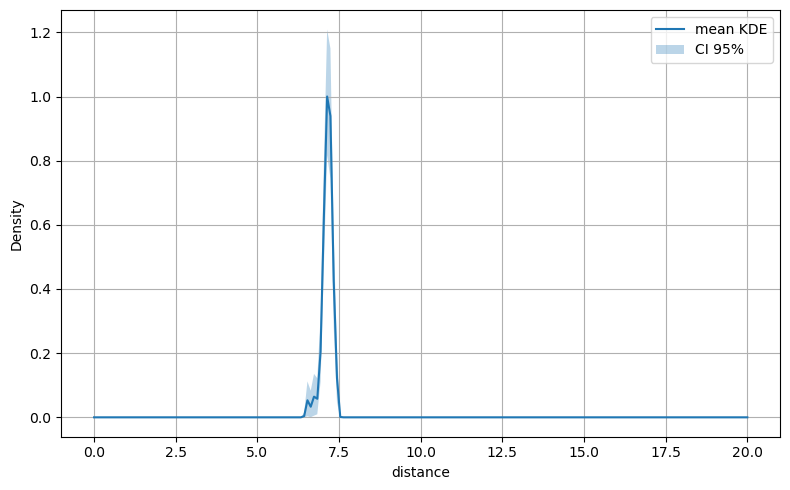

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.355630397796631, 7.243984222412109, 7.181778907775879, 7.25632905960083, 7.215877532958984]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

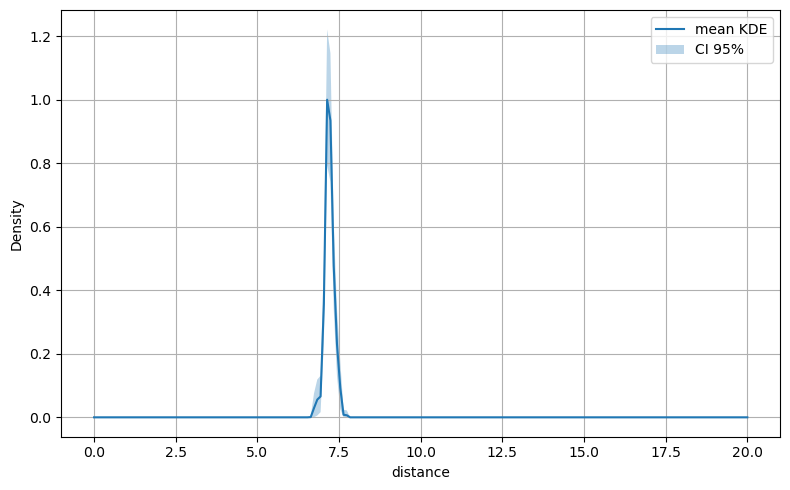

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.236205101013184, 7.026934623718262, 7.198823928833008, 7.1064276695251465, 7.000904083251953]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

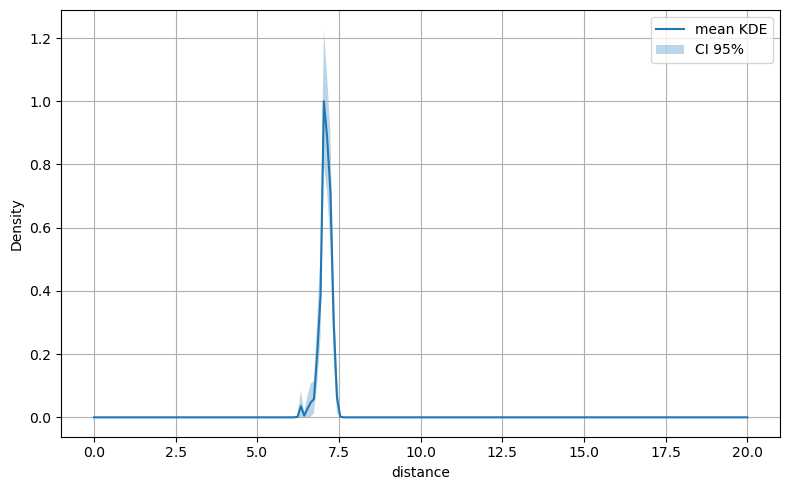

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [4.680820465087891, 4.899626731872559, 4.429839611053467, 5.018469333648682, 4.991652488708496]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

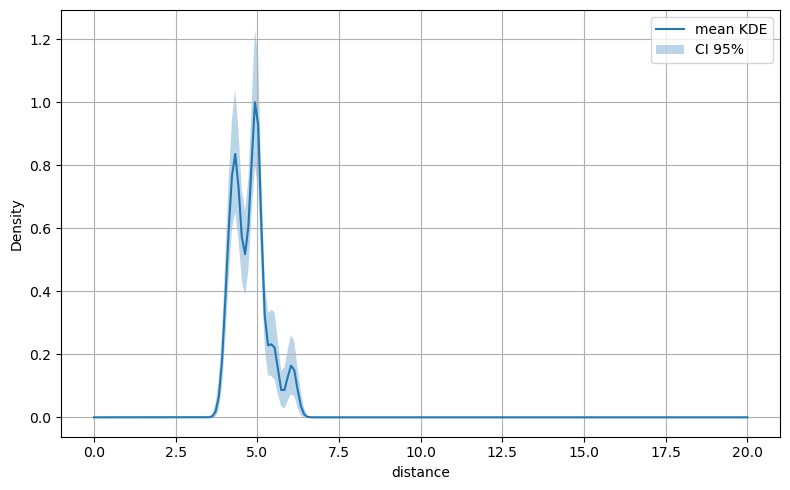

In [29]:
input_data = [
    ["coordinates/aligned_glca_af3.pdb", 644, 997],
    ["coordinates/aligned_glc_af3.pdb", 644, 972],
    ["coordinates/aligned_ugb_af3.pdb", 644, 974],
    ["coordinates/aligned_gal_af3.pdb", 644, 972],
    ["coordinates/aligned_glcnac_af3.pdb", 644, 987],
    ["coordinates/aligned_galnac_af3.pdb", 644, 987],
    ["coordinates/aligned_ugb_boltz.pdb", 644, 973],
    ["coordinates/aligned_gal_boltz.pdb", 644, 971],
    ["coordinates/aligned_galnac_boltz.pdb", 644, 986],
    ["coordinates/aligned_glc_boltz.pdb", 644, 971],
    ["coordinates/aligned_glca_boltz.pdb", 644, 996],
    ["coordinates/aligned_glcnac_boltz.pdb", 644, 996]
]
for ind in input_data:
    outfile = ind[0].split("/")[-1].replace(".pdb", "_kde.csv")
    df_kde = bootstrap_kde(
        [distances_from_multistate_pdb(*ind)],
        output_csv=f"output/{outfile}",
        n_bootstrap=4000,
        confidence_level=95,
        x_min=0.0,
        x_max=20.0,
        n_points=200,
        bw_scale=0.6,
    )

In [31]:
!tail -n +1 confidences/boltz/affinity_GumK*

==> confidences/boltz/affinity_GumK_UDP-Gal.json <==
{
    "affinity_pred_value": -0.2512030005455017,
    "affinity_probability_binary": 0.8513375520706177,
    "affinity_pred_value1": 1.7783929109573364,
    "affinity_probability_binary1": 0.7338086366653442,
    "affinity_pred_value2": -2.28079891204834,
    "affinity_probability_binary2": 0.9688665270805359
}
==> confidences/boltz/affinity_GumK_UDP-GalNAc.json <==
{
    "affinity_pred_value": -0.17207342386245728,
    "affinity_probability_binary": 0.6155726313591003,
    "affinity_pred_value1": 1.1551213264465332,
    "affinity_probability_binary1": 0.4695875644683838,
    "affinity_pred_value2": -1.4992681741714478,
    "affinity_probability_binary2": 0.7615576982498169
}
==> confidences/boltz/affinity_GumK_UDP-GlcA.json <==
{
    "affinity_pred_value": -0.6550031304359436,
    "affinity_probability_binary": 0.8507941961288452,
    "affinity_pred_value1": 1.0562728643417358,
    "affinity_probability_binary1": 0.7235854864120483,

In [16]:
10**1.225355625152588

16.80179281833723

In [17]:
10**-0.2512030005455017

0.5607857888857489

In [18]:
10**-0.17207342386245728

0.6728628893110224

In [19]:
10**-0.6550031304359436

0.2213078757465913

In [20]:
10**-0.25368553400039673

0.5575893447217104

In [21]:
10**-0.1348899006843567

0.7330103372671377

In [32]:
10**-0.7581222653388977

0.17453307271656363